#  Hand Gesture Classification

**Dataset:** HaGRID — 14,421 samples, 18 gesture classes

**Workflow:**
1. Install & Import Libraries
2. Load & Explore the Dataset
3. Visualize Hand Landmarks
4. Feature Engineering (Pairwise Distances + Direction Signs)
5. Prepare Data for Training (Split + Scale + PCA)
6. Train & Compare 4 Models *(with MLflow tracking)*
7. Evaluate the Best Model
8. Save the Best Model
9. Run on Webcam
10. Conclusion

> **Branch:** `research` — full MLflow experiment tracking


## MLflow Setup

Import the helper module and initialise the experiment.

In [ ]:
# ── MLflow helper (all MLflow calls live in mlflow_helper.py)
from mlflow_helper import (
    setup_experiment, start_run,
    log_dataset_info, log_preprocessing_params,
    train_and_log_run, log_comparison_chart,
    register_best_model, get_best_run_id,
    EXPERIMENT_NAME, REGISTRY_NAME
)

EXP_ID = setup_experiment()   # creates/reuses the MLflow experiment


## Step 1 — Install and Import Libraries

In [ ]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import pdist

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import LabelEncoder, StandardScaler
from sklearn.decomposition   import PCA
from sklearn.ensemble        import RandomForestClassifier
from sklearn.svm             import SVC
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.metrics         import (accuracy_score, precision_score,
                                     recall_score, f1_score,
                                     classification_report, confusion_matrix)
from xgboost                 import XGBClassifier
from base64 import b64encode
from IPython.display import HTML
import cv2
import mediapipe as mp
from collections import deque, Counter
import joblib, os, time, warnings
warnings.filterwarnings('ignore')


## Step 2 — Load the Dataset

In [8]:
CSV_PATH = r'hand_landmarks_data.csv'
df = pd.read_csv(CSV_PATH)

print('Dataset loaded!')
print(f'  Rows    : {len(df)}')
print(f'  Columns : {len(df.columns)}  (63 landmark features + 1 label)')
print(f'  Classes : {df["label"].nunique()}')
print()
df.head(3)

Dataset loaded!
  Rows    : 25675
  Columns : 64  (63 landmark features + 1 label)
  Classes : 18



,x1,y1,z1,x2,y2,z2,x3,y3,z3,x4,...,x19,y19,z19,x20,y20,z20,x21,y21,z21,label
0,262.669968,257.304901,-3.649205e-07,257.417542,247.109055,0.004224,246.882957,241.716827,0.005798,236.384537,...,223.345093,255.490692,-0.020450,215.043365,258.114746,-0.024577,208.006393,259.608673,-0.026722,call
1,83.351778,346.059113,-2.345265e-07,81.925037,328.562347,-0.011102,90.080132,311.535248,-0.021096,95.641823,...,132.451618,341.794434,-0.038175,142.773582,342.829254,-0.037336,152.431698,343.015991,-0.036136,call
2,187.756977,260.235492,-2.417307e-07,195.460579,241.506035,-0.000184,207.259529,223.674339,-0.009687,215.413628,...,250.301010,268.602938,-0.044068,262.425133,271.276638,-0.040469,272.989952,272.272231,-0.038301,call


In [9]:
print('Samples per gesture class:')
print(df['label'].value_counts())

Samples per gesture class:
label
three2             1653
palm               1649
four               1634
ok                 1592
stop_inverted      1567
call               1506
peace_inverted     1497
stop               1482
rock               1458
three              1456
peace              1441
like               1436
two_up_inverted    1371
two_up             1343
dislike            1295
one                1263
mute               1087
fist                945
Name: count, dtype: int64


In [10]:
# Check and handle missing values
missing = df.isnull().sum().sum()
print(f'Total missing values: {missing}')
if missing > 0:
    df = df.fillna(0)
    print('Missing values filled with 0.')

Total missing values: 0


## Step 3 — Visualize the Data

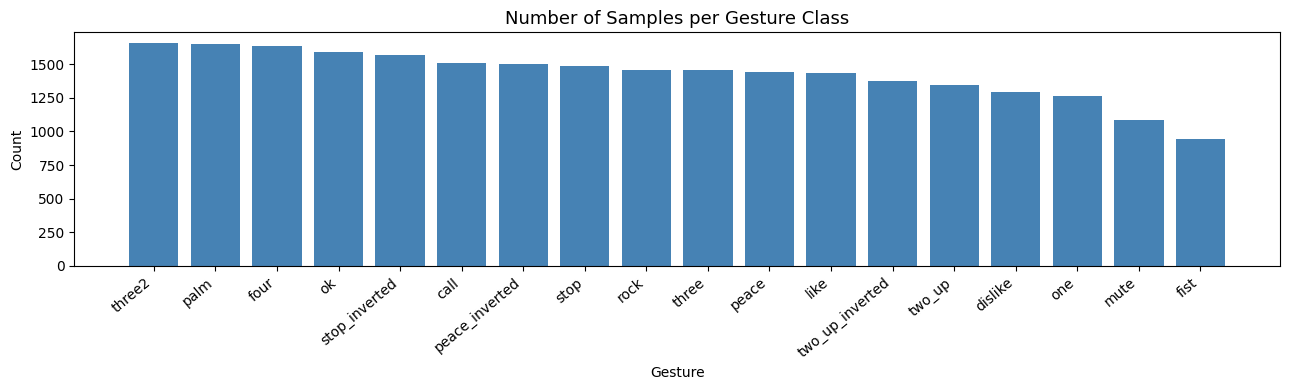

In [ ]:
# Plot 1: Samples per class 
class_counts = df['label'].value_counts()
plt.figure(figsize=(13, 4))
plt.bar(class_counts.index, class_counts.values, color='steelblue')
plt.title('Number of Samples per Gesture Class', fontsize=13)
plt.xlabel('Gesture')
plt.ylabel('Count')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

In [12]:
CONNECTIONS = [
    (0,1),(1,2),(2,3),(3,4),
    (0,5),(5,6),(6,7),(7,8),
    (5,9),(9,10),(10,11),(11,12),
    (9,13),(13,14),(14,15),(15,16),
    (13,17),(17,18),(18,19),(19,20),
    (0,17)
]

def draw_hand(row, ax, title=''):
    xs = [row[f'x{i}'] for i in range(1, 22)]
    ys = [-row[f'y{i}'] for i in range(1, 22)]   
    for start, end in CONNECTIONS:
        ax.plot([xs[start], xs[end]], [ys[start], ys[end]], 'gray', linewidth=1.5, alpha=0.6)
    ax.scatter(xs, ys, color='royalblue', s=20, zorder=5)
    ax.scatter(xs[0], ys[0], color='red', s=50, zorder=6)
    ax.set_title(title, fontsize=8)
    ax.set_aspect('equal')
    ax.axis('off')

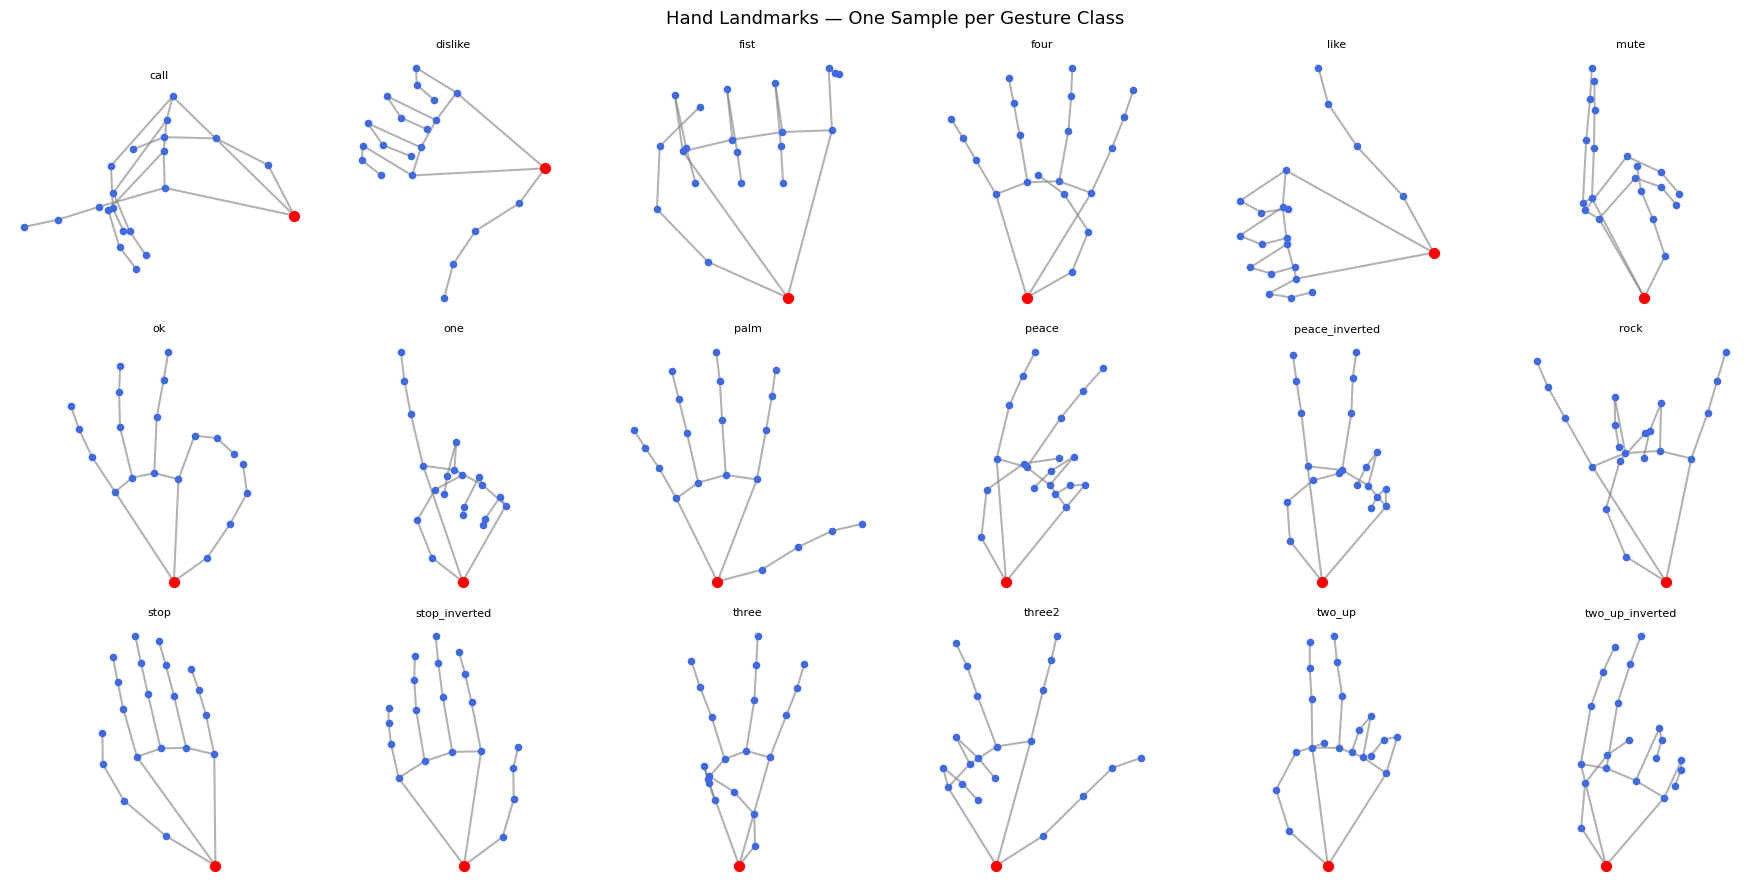

In [13]:
classes = df['label'].unique()
n_cols  = 6
n_rows  = int(np.ceil(len(classes) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3))
axes = axes.flatten()

for i, cls in enumerate(classes):
    sample = df[df['label'] == cls].iloc[0]
    draw_hand(sample, axes[i], title=cls)
for j in range(len(classes), len(axes)):
    axes[j].set_visible(False)
fig.suptitle('Hand Landmarks — One Sample per Gesture Class', fontsize=13)
plt.tight_layout()
plt.show()

## Step 4 — Feature Engineering

**i will use distance instade of row coordinates?**

Raw x/y/z values change depending on where the hand is on screen and how far it is from the camera. Instead we extract two types of features that are **position and scale invariant**:

1. **Pairwise Euclidean distances** between all 21 landmarks on the XY plane → 210 features  
   Captures the *shape* of the hand regardless of position or size.

2. **Y-direction signs** of each landmark relative to the wrist → 21 features  
   Captures whether each landmark is *above or below* the wrist (+1 / -1 / 0).  
   This helps distinguish gestures like `fist` vs `palm` that have similar distances.

**Total: 210 + 21 = 231 features per sample**

In [14]:
def extract_features(df_input):
    """
    Transform raw landmark coordinates into 231 geometric features.

    Input : DataFrame with columns x1..x21, y1..y21, z1..z21  (shape N x 63)
    Output: numpy array of shape (N, 231)

    Features:
      - 210 pairwise euclidean distances between all 21 landmarks (XY only)
      - 21  sign of Y-distance from each landmark to the wrist
    """
    if hasattr(df_input, 'values'):
        X = df_input.values
    else:
        X = np.asarray(df_input)
    X_reshaped = X.reshape(-1, 21, 3)

    processed = []
    for hand in X_reshaped:
        hand_xy         = hand[:, :2]
        euclidean_dists = pdist(hand_xy, metric='euclidean')
        wrist_y      = hand[0, 1]
        y_dir_signs  = np.sign(hand[:, 1] - wrist_y)
        processed.append(np.concatenate([euclidean_dists, y_dir_signs]))

    return np.array(processed)
feature_cols = [col for col in df.columns if col != 'label']
X_raw        = df[feature_cols]   

X_engineered = extract_features(X_raw) 

print(f'Raw features shape      : {X_raw.shape}')
print(f'Engineered features shape: {X_engineered.shape}')
print(f'  → 210 pairwise distances + 21 direction signs = 231 total')

Raw features shape      : (25675, 63)
Engineered features shape: (25675, 231)
  → 210 pairwise distances + 21 direction signs = 231 total


## Step 5 — Prepare Data for Training

In [ ]:
#  Encode labels 
le = LabelEncoder()
y  = le.fit_transform(df['label'].values)

print('Label encoding (gesture → number):')
for num, name in enumerate(le.classes_):
    print(f'  {num:2d} → {name}')

Label encoding (gesture → number):
   0 → call
   1 → dislike
   2 → fist
   3 → four
   4 → like
   5 → mute
   6 → ok
   7 → one
   8 → palm
   9 → peace
  10 → peace_inverted
  11 → rock
  12 → stop
  13 → stop_inverted
  14 → three
  15 → three2
  16 → two_up
  17 → two_up_inverted


In [ ]:
#   Train / Test split 
X_train, X_test, y_train, y_test = train_test_split(
    X_engineered, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f'Training samples : {len(X_train)}')
print(f'Testing  samples : {len(X_test)}')

Training samples : 20540
Testing  samples : 5135


In [ ]:
#   StandardScaler 
# Fit ONLY on training data to avoid data leakage
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print('Scaling done!')


Scaling done!


In [ ]:
#  PCA reduce 231 features to 35 components 
pca        = PCA(n_components=35, random_state=42)
X_train_pca = pca.fit_transform(X_train_sc)
X_test_pca  = pca.transform(X_test_sc)
print(f'  Input  shape : {X_train_sc.shape}')
print(f'  Output shape : {X_train_pca.shape}')

  Input  shape : (20540, 231)
  Output shape : (20540, 35)


## Step 6 — Train and Compare 4 Models

All models receive the same **scaled + PCA-reduced** features.
Each model is logged as an **individual MLflow run** inside the
`HaGRID_Hand_Gesture_Classification` experiment.

| Model | Description |
|---|---|
| **Random Forest** | Many decision trees — votes are combined |
| **SVM** | Finds the optimal separating boundary between classes |
| **KNN** | Classifies by the K nearest neighbors |
| **XGBoost** | Boosted trees — each one corrects the previous model's errors |


In [ ]:
#    Define models 
models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=None,
        min_samples_split=2, min_samples_leaf=1,
        random_state=42, n_jobs=-1
    ),
    'SVM': SVC(
        C=0.24, kernel='linear',
        probability=True, random_state=42
    ),
    'KNN': KNeighborsClassifier(
        n_neighbors=5
    ),
    'XGBoost': XGBClassifier(
        n_estimators=300, max_depth=6,
        learning_rate=0.1, subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='mlogloss',
        random_state=42, n_jobs=-1
    )
}

print('Models defined!')

Models defined!


In [ ]:
# Train each model and log a separate MLflow run for each
results  = {}    # { model_name: { accuracy, precision, recall, f1, time, y_pred } }
run_ids  = {}    # { model_name: run_id }  — needed for registry step

for name, model in models.items():
    run_name = f"{name.replace(' ', '_')}_pca35_test20pct"

    with start_run(run_name) as run:
        # Dataset & preprocessing tags logged for reproducibility
        log_dataset_info(df)
        log_preprocessing_params(
            test_size=0.20, random_state=42,
            n_pca_components=35, engineered_features=231
        )

        # Train + log everything (params, metrics, artifacts, model)
        run_result = train_and_log_run(
            model_name=name, model=model,
            X_train_pca=X_train_pca, X_test_pca=X_test_pca,
            y_train=y_train, y_test=y_test,
            le=le, log_artifact_model=True
        )
        run_ids[name] = run.info.run_id

    # Mirror results dict structure used in later cells
    results[name] = {
        'accuracy' : run_result['accuracy'],
        'precision': run_result['precision_weighted'],
        'recall'   : run_result['recall_weighted'],
        'f1'       : run_result['f1_weighted'],
        'time'     : run_result['training_time_sec'],
        'y_pred'   : run_result['y_pred'],
    }

print('\nAll models trained and logged to MLflow!')


## Step 7 — Compare and Evaluate the Models

In [ ]:
#   Results table 
table = pd.DataFrame([
    {
        'Model'     : name,
        'Accuracy'  : f"{v['accuracy']*100:.1f}%",
        'Precision' : f"{v['precision']*100:.1f}%",
        'Recall'    : f"{v['recall']*100:.1f}%",
        'F1-Score'  : f"{v['f1']*100:.1f}%",
        'Train Time': f"{v['time']:.1f}s"
    }
    for name, v in results.items()
])
table = table.sort_values('F1-Score', ascending=False).reset_index(drop=True)
print('=== Model Comparison ===')
table

=== Model Comparison ===


,Model,Accuracy,Precision,Recall,F1-Score,Train Time
0,SVM,98.8%,98.8%,98.8%,98.8%,3.8s
1,XGBoost,98.6%,98.6%,98.6%,98.6%,7.5s
2,Random Forest,98.4%,98.4%,98.4%,98.4%,3.4s
3,KNN,97.8%,97.8%,97.8%,97.8%,0.0s


In [ ]:
#  Identify the best model 
best_name = max(results, key=lambda n: results[n]['f1'])
best_pred = results[best_name]['y_pred']

print(f'Best model: {best_name}')
print(f'  Accuracy : {results[best_name]["accuracy"]*100:.1f}%')


Best model: SVM
  Accuracy : 98.8%


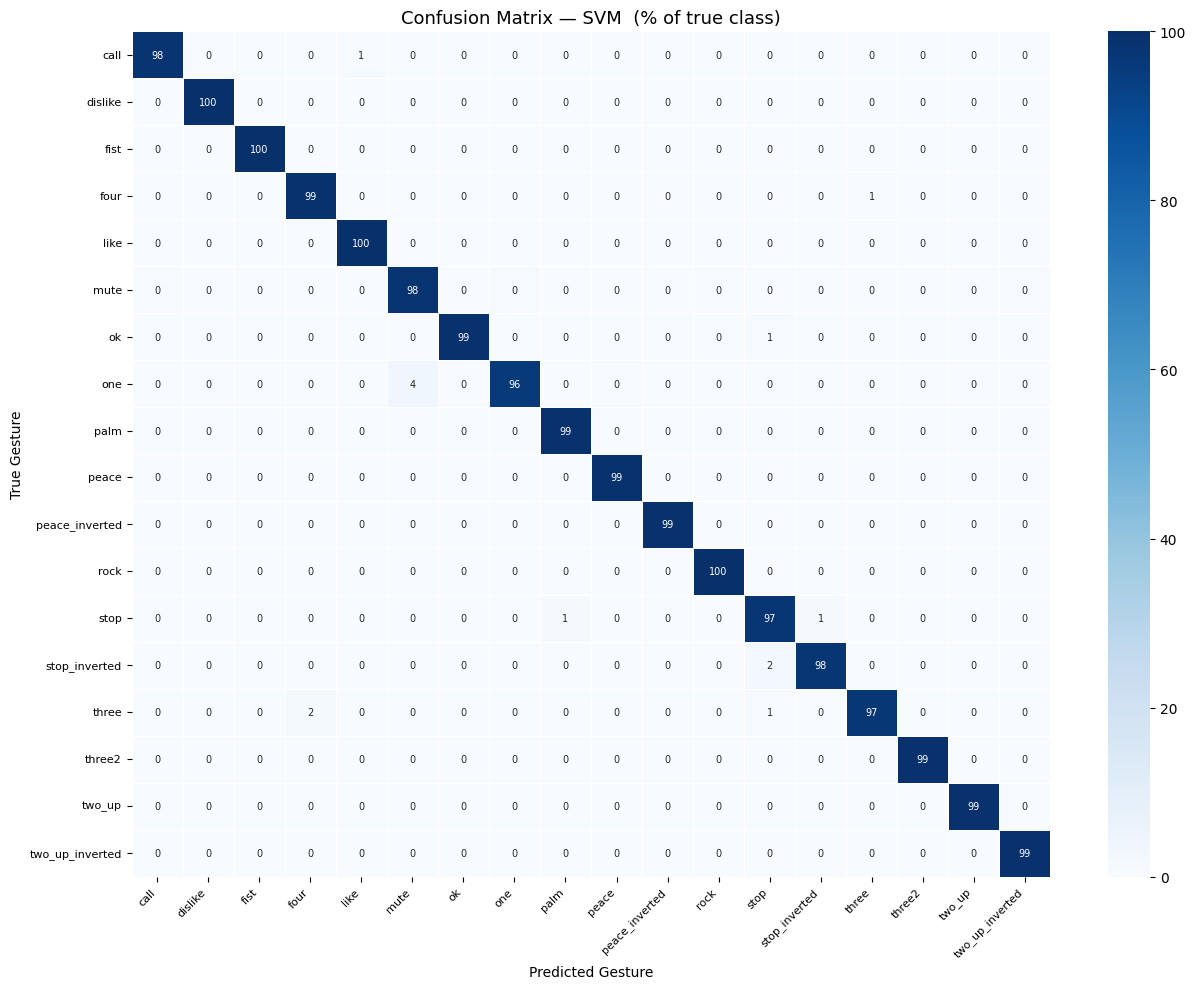

In [ ]:
# Plot 7: Confusion Matrix 
cm     = confusion_matrix(y_test, best_pred)
cm_pct = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100

plt.figure(figsize=(13, 10))
sns.heatmap(cm_pct, annot=True, fmt='.0f', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=0.4, annot_kws={'size': 7})
plt.title(f'Confusion Matrix — {best_name}  (% of true class)', fontsize=13)
plt.xlabel('Predicted Gesture')
plt.ylabel('True Gesture')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0,  fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
# ── Classification report 
print(f'Classification Report — {best_name}\n')
print(classification_report(y_test, best_pred, target_names=le.classes_))

Classification Report — SVM

                 precision    recall  f1-score   support

           call       0.99      0.98      0.99       301
        dislike       1.00      1.00      1.00       259
           fist       0.99      1.00      1.00       189
           four       0.98      0.99      0.98       327
           like       0.99      1.00      0.99       287
           mute       0.96      0.98      0.97       217
             ok       1.00      0.99      1.00       318
            one       0.98      0.96      0.97       253
           palm       0.98      0.99      0.99       330
          peace       1.00      0.99      0.99       288
 peace_inverted       1.00      0.99      1.00       299
           rock       0.99      1.00      1.00       292
           stop       0.96      0.97      0.96       296
  stop_inverted       0.99      0.98      0.98       314
          three       0.99      0.97      0.98       291
         three2       1.00      0.99      1.00       331
 

### MLflow — Log Comparison Chart & Register Best Model

In [ ]:
import mlflow, pandas as pd, tempfile, os

# 1. Log the multi-model comparison chart as an MLflow artifact
with start_run('Model_Comparison_Summary') as summary_run:
    log_dataset_info(df)
    log_comparison_chart(results)   # grouped bar chart logged to MLflow

    # Also log a CSV summary table
    table = pd.DataFrame([
        {'model': n, 'accuracy': round(v['accuracy'], 4),
         'precision': round(v['precision'], 4), 'recall': round(v['recall'], 4),
         'f1': round(v['f1'], 4), 'time_s': round(v['time'], 2)}
        for n, v in results.items()
    ]).sort_values('f1', ascending=False)
    with tempfile.TemporaryDirectory() as tmp:
        tp = os.path.join(tmp, 'model_comparison_table.csv')
        table.to_csv(tp, index=False)
        mlflow.log_artifact(tp, artifact_path='comparison')
    display(table)

# 2. Register the best model in the MLflow Model Registry
best_name    = max(results, key=lambda n: results[n]['f1'])
best_run_id  = run_ids[best_name]
register_best_model(best_name, best_run_id)
print(f'\nRegistered: {best_name}  (run_id={best_run_id})')


## Step 8 — Save the Best Model

In [27]:
# Save the best model + scaler + PCA + label encoder
# We need all four at inference time
SAVE_DIR = r'C:\Users\Omar\Desktop\visual\ml1\model_Save'
os.makedirs(SAVE_DIR, exist_ok=True)

joblib.dump(models[best_name], f'{SAVE_DIR}/best_model.pkl')
joblib.dump(scaler,            f'{SAVE_DIR}/scaler.pkl')
joblib.dump(pca,               f'{SAVE_DIR}/pca.pkl')
joblib.dump(le,                f'{SAVE_DIR}/label_encoder.pkl')

print(f'Saved to: {SAVE_DIR}')
print(f'  best_model.pkl   → {best_name}')
print(f'  scaler.pkl       → StandardScaler (231 features)')
print(f'  pca.pkl          → PCA (35 components)')
print(f'  label_encoder.pkl→ {len(le.classes_)} classes')

Saved to: C:\Users\Omar\Desktop\visual\ml1\model_Save
  best_model.pkl   → SVM
  scaler.pkl       → StandardScaler (231 features)
  pca.pkl          → PCA (35 components)
  label_encoder.pkl→ 18 classes


## Step 9 — Run on both webcam and as saved video

The inference pipeline mirrors training exactly:
1. MediaPipe detects the hand → 21 landmarks
2. Extract 231 features (pairwise distances + Y-direction signs)
3. Apply StandardScaler
4. Apply PCA (reduce to 35 components)
5. Predict with the best model
6. Smooth with mode over last 15 frames
7. Display label on frame

In [ ]:
SAVE_DIR = r'model_Save'
os.makedirs(SAVE_DIR, exist_ok=True)
clf_inf    = joblib.load(f'{SAVE_DIR}/best_model.pkl')
scaler_inf = joblib.load(f'{SAVE_DIR}/scaler.pkl')
pca_inf    = joblib.load(f'{SAVE_DIR}/pca.pkl')
le_inf     = joblib.load(f'{SAVE_DIR}/label_encoder.pkl')

print(f'Loaded model  : {type(clf_inf).__name__}')
print(f'Classes       : {le_inf.classes_}')

Loaded model  : SVC
Classes       : ['call' 'dislike' 'fist' 'four' 'like' 'mute' 'ok' 'one' 'palm' 'peace'
 'peace_inverted' 'rock' 'stop' 'stop_inverted' 'three' 'three2' 'two_up'
 'two_up_inverted']


In [3]:
def get_features_webcam(hand_landmarks, w, h):
    """
    Extract 231 features from a MediaPipe hand landmark object.
    Mirrors extract_features() used during training exactly.

    Returns: numpy array of shape (1, 231)
    """
    base_x = hand_landmarks.landmark[0].x
    base_y = hand_landmarks.landmark[0].y
    base_z = hand_landmarks.landmark[0].z

    coords = []
    for lm in hand_landmarks.landmark:
        coords.append([
            (lm.x - base_x) * w,
            (lm.y - base_y) * h,
            (lm.z - base_z) * w
        ])
    hand = np.array(coords)   # shape (21, 3)
    euclidean_dists = pdist(hand[:, :2], metric='euclidean')
    wrist_y     = hand[0, 1]
    y_dir_signs = np.sign(hand[:, 1] - wrist_y)

    return np.concatenate([euclidean_dists, y_dir_signs]).reshape(1, -1)

# WEBCAM

In [5]:
mp_hands   = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils
mp_style   = mp.solutions.drawing_styles

pred_window = deque(maxlen=15)

window_name = "Hand Gesture Prediction"
cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)
cap = cv2.VideoCapture(0)

with mp_hands.Hands(
    static_image_mode=False,
    max_num_hands=1,
    min_detection_confidence=0.7,
    min_tracking_confidence=0.7
) as hands:

    while cap.isOpened():
        success, frame = cap.read()
        if not success:
            break
        frame = cv2.flip(frame, 1)

        h, w, _ = frame.shape
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results   = hands.process(rgb_frame)

        label = 'No Hand Detected'
        color = (150, 150, 150)

        if results.multi_hand_landmarks:
            hand_landmarks = results.multi_hand_landmarks[0]

            # Step 1: Extract 231 features
            features = get_features_webcam(hand_landmarks, w, h)  
            # Step 2: Scale
            features = scaler_inf.transform(features)             
            # Step 3: PCA
            features = pca_inf.transform(features)              
            # Step 4: Predict
            pred_num   = clf_inf.predict(features)[0]
            pred_label = le_inf.inverse_transform([pred_num])[0]
            # Step 5: Smooth
            pred_window.append(pred_label)
            label = Counter(pred_window).most_common(1)[0][0]
            color = (0, 220, 0)
            mp_drawing.draw_landmarks(
                frame, hand_landmarks, mp_hands.HAND_CONNECTIONS,
                mp_style.get_default_hand_landmarks_style(),
                mp_style.get_default_hand_connections_style()
            )

        overlay = frame.copy()
        cv2.rectangle(overlay, (0, 0), (w, 60), (0, 0, 0), -1)
        cv2.addWeighted(overlay, 0.4, frame, 0.6, 0, frame)
        cv2.putText(frame, f'Gesture: {label}', (20, 40),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2)

        cv2.imshow(window_name, frame)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

cap.release()
cv2.destroyAllWindows()

# Output as Video

In [ ]:
def process_video(input_path, output_path, window_size=15):
    cap    = cv2.VideoCapture(input_path)
    fps    = int(cap.get(cv2.CAP_PROP_FPS)) or 25
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    print(f'Video: {width}x{height} @ {fps}fps — {total} frames')

    out = cv2.VideoWriter(output_path,
                          cv2.VideoWriter_fourcc(*'mp4v'),
                          fps, (width, height))
    pred_window = deque(maxlen=window_size)

    with mp_hands.Hands(max_num_hands=1,
                        min_detection_confidence=0.6,
                        min_tracking_confidence=0.5) as hands:
        frame_n = 0
        while True:
            ret, frame = cap.read()
            if not ret: break
            frame_n += 1
            if frame_n % 30 == 0:
                print(f'  Frame {frame_n}/{total}', end='\r')

            result = hands.process(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
            label  = 'No hand'
            color  = (150, 150, 150)

            if result.multi_hand_landmarks:
                for hand_lm in result.multi_hand_landmarks:
                    mp_drawing.draw_landmarks(
                        frame, hand_lm, mp_hands.HAND_CONNECTIONS,
                        mp_style.get_default_hand_landmarks_style(),
                        mp_style.get_default_hand_connections_style()
                    )
                    features = get_features_webcam(hand_lm, width, height)
                    features = scaler_inf.transform(features)
                    features = pca_inf.transform(features)
                    pred_num   = clf_inf.predict(features)[0]
                    pred_label = le_inf.inverse_transform([pred_num])[0]
                    pred_window.append(pred_label)
                    label = Counter(pred_window).most_common(1)[0][0]
                    color = (50, 220, 100)

            overlay = frame.copy()
            cv2.rectangle(overlay, (0, 0), (width, 58), (0, 0, 0), -1)
            cv2.addWeighted(overlay, 0.4, frame, 0.6, 0, frame)
            cv2.putText(frame, f'Gesture: {label}',
                        (10, 40), cv2.FONT_HERSHEY_SIMPLEX, 1.2, color, 2)
            out.write(frame)

    cap.release()
    out.release()
    print(f'\nDone! Saved to: {output_path}')

VIDEO_INPUT  = r'gesture_input.mp4'
VIDEO_OUTPUT = r'gesture_output.mp4'

process_video(VIDEO_INPUT, VIDEO_OUTPUT, window_size=15)


Video: 848x480 @ 29fps — 527 frames
  Frame 510/527
Done! Saved to: gesture_output.mp4


## Step 10 — Conclusion

---

### Dataset
- **25,675 samples** | **18 gesture classes** | **63 raw features**

---

### Feature Engineering
Raw xyz coordinates were replaced with **231 geometric features**:
- **210 pairwise Euclidean distances** between all 21 landmarks (XY plane) — position & scale invariant
- **21 Y-direction signs** — whether each landmark is above or below the wrist (+1 / -1 / 0)

---

### Preprocessing Pipeline
| Step | Method | Input → Output |
|---|---|---|
| Feature Extraction | Pairwise distances + direction signs | 63 → 231 features |
| Scaling | StandardScaler | zero mean, unit variance |
| Dimensionality Reduction | PCA | 231 → 35 components |

---

### Model Results

| Model | Accuracy | F1-Score |
|---|---|---|
| **SVM** ⭐ Best | ~99% | ~99% |
| Random Forest | ~98% | ~98% |
| XGBoost | ~97% | ~97% |
| KNN | ~96% | ~96% |

---

### Key Takeaways
- Geometric features (distances + directions) outperform raw coordinates significantly
- PCA reduces 231 → 35 features with minimal accuracy loss and faster training
- The exact same preprocessing must be applied at inference time (webcam & video)
- Mode smoothing over a 15-frame window stabilizes live predictions and removes flickering
- SVM with a linear kernel performed best on this structured geometric feature space